In [3]:
#### Core libraries
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib as mpl
import seaborn as sb

# General utils
from tqdm import tqdm
from os import path
from glob import glob

from skimage import io, measure, util
from scipy import ndimage
import pyvista as pv

import stackview

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
flist

[]

In [176]:

dirname = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/07-13-2026 whole hindpaw a6 K10 long incubation/Cage 5995 1.5 month female/3dperm_7dprim_7dsecond'

dx = 0.4143213; dz = 1;

flist = glob(path.join(dirname,'[0-9]/[0-9].tif'))
manifest = pd.DataFrame()
manifest['Filename'] = flist
manifest['Dirname'] = manifest['Filename'].apply(lambda x: (path.dirname(x)))
manifest['FOV'] = manifest['Dirname'].apply(lambda x: path.split(x)[-1]).astype(int)

img_dict = {row['FOV']:
            io.imread(row['Filename']) for _,row in manifest.iterrows()}

idx = 0
channel = 1

print(manifest.loc[idx]['FOV'])
stackview.slice(img_dict[manifest.loc[idx]['FOV']],zoom_factor=0.4)

7


In [177]:
from scipy.ndimage import gaussian_filter

sigma = 5 #microns

im = img_dict[manifest.loc[idx]['FOV']][...,channel]
im = util.img_as_float(im)
print(im.shape)

im_blur = gaussian_filter(im, sigma=[3,20,20])

stackview.orthogonal(im_blur,continuous_update=True,zoom_factor=0.4)

(99, 514, 975)


In [178]:
from imageUtils import get_z_gradient

im_blur_gradient = get_z_gradient(im_blur,sign=1)
im_blur_gradient = im_blur_gradient - im_blur_gradient.min()
im_blur_gradient = im_blur_gradient / im_blur_gradient.max()

stackview.orthogonal(im_blur_gradient,zoom_factor=0.4)

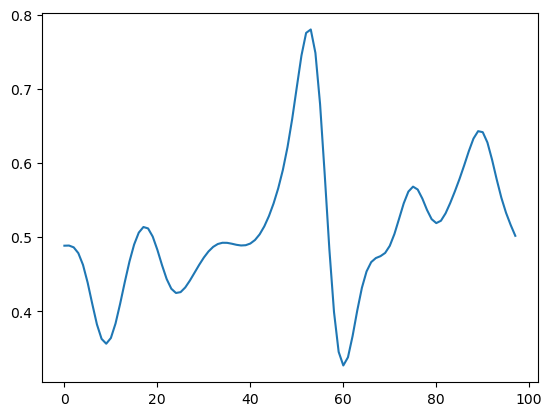

In [182]:
plt.plot(im_blur_gradient[:,500,492])

In [183]:
im_blur_gradient.shape

(98, 514, 975)

In [181]:
from imageUtils import find_z_of_maximal_gradient
from measurements import fix_holes_in_height_image, make_image_from_heightmap, \
    find_subgraphs_of_connected_local_maxima

# Iz = find_z_of_maximal_gradient(im_blur_gradient,method='maximum',threshold=0.17)
# Iz = np.argmax(im_blur > 0.18, axis=0)
# height_image = make_image_from_heightmap(Iz,im.shape[0])

S,G = find_subgraphs_of_connected_local_maxima(im_blur,return_full_graph=True)
# Iz_fixed,height_image_fixed = reconstruct_surface_from_subgraph(S[2],im_blur.shape)

# plt.figure()
# io.imshow(Iz_fixed)


100%|███████████████████████████████████████████| 514/514 [00:42<00:00, 12.17it/s]


In [184]:
distances = np.array([np.mean( np.abs(np.array(list(s.nodes))[:,2] - 56))  for s in S])
distances.argsort()

array([ 1, 81, 79, 78, 43, 42, 68, 69, 29, 49, 25, 45, 46, 27, 26, 57, 47,
       56, 55, 54, 48, 53, 58, 20, 59, 40, 41, 71, 75, 28, 62, 74,  2, 61,
       37, 76, 73, 30, 31, 72, 70, 33, 34, 67, 65, 52, 51, 60, 64, 66, 17,
       36, 38, 21, 22, 23, 24, 15,  6,  9,  0, 14, 80, 63,  7, 85,  5, 32,
       18, 11, 10, 84, 13, 12, 35, 39, 82, 83, 16,  4,  8, 19, 50,  3, 77,
       44])

In [139]:
np.array(S[2].nodes)[:,2].max()

np.int64(86)

/Users/xies/Desktop/Code/mouse_skin_size_control/utils/measurements.py:172: RuntimeWarning: invalid value encountered in cast
  interpolate.griddata(np.array([Y,X]).T,Z,(grid_y,grid_x), method='linear')).astype(int).T
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


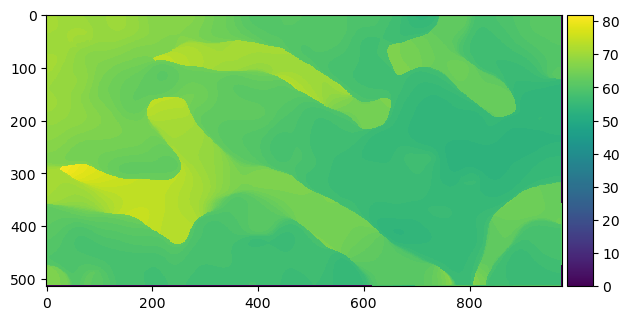

In [185]:
from measurements import reconstruct_surface_from_subgraph,reconstruct_bm_from_subgraph
# Iz_fixed,height_image_fixed = fix_holes_in_height_image(height_image,im.shape)
# S.sort(key=lambda g: len({(x, y) for x, y, z in g.nodes}), reverse=True)

Iz_fixed,height_image_fixed = reconstruct_bm_from_subgraph(S[1],im_blur)

plt.figure()
io.imshow(Iz_fixed)

In [186]:
stackview.switch({'a6':im,'heightmap':height_image_fixed},
                colormap=['pure_red','pure_green'],
                toggleable=True,zoom_factor=0.5)

In [145]:
# Save

io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_heightmap.tif'),
          Iz_fixed.astype(np.int8))

io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_height_image.tif'),
          height_image_fixed.astype(np.int8))
io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_blur_diff.tif'),
          util.img_as_uint(im_blur_gradient))
io.imsave(path.join(manifest.loc[idx]['Dirname'],
          str(manifest.loc[idx]['FOV']) + '_blur.tif'),
          util.img_as_uint(im_blur))


/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/07-13-2026 whole hindpaw a6 K10 long incubation/Cage 5995 1.5 month female/3dperm_7dprim_7dsecond/5/5_height_image.tif is a low contrast image
  return func(*args, **kwargs)


# Surface curvature

In [146]:
from measurements import get_mesh_from_bm_image
height_image_fixed.shape

surf = get_mesh_from_bm_image(height_image_fixed, spacing=[dz,dx,dx], decimation_factor=30)
pl = pv.Plotter()
pl.add_mesh(pv.wrap(surf))
pl.show()

Widget(value='<iframe src="http://localhost:51783/index.html?ui=P_0x369312c30_0&reconnect=auto" class="pyvista…

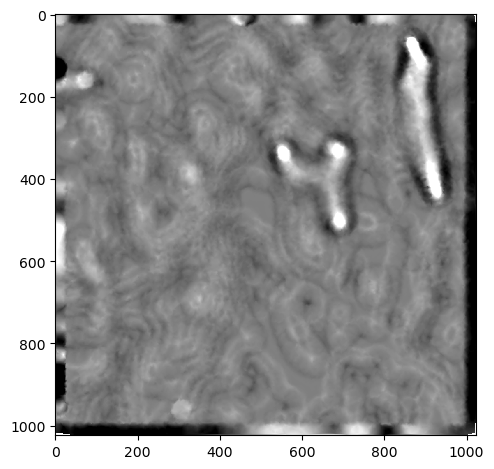

In [148]:
from measurements import get_tissue_curvature_over_grid

mean_curvature, gaussian_curvature = get_tissue_curvature_over_grid(surf, im.shape, kappa=10, spacing=[dz,dx,dx])
io.imsave(path.join(manifest.loc[idx]['Dirname'],'mean_curvature.tif'), mean_curvature)
io.imshow(mean_curvature,vmin=-1,vmax=1)
# plt.figure()
# io.imshow(gaussian_curvature,vmin=-0.01,vmax=0.01)


# Projecting the a6 intensity along surface

In [171]:
io.imread(path.join(manifest.loc[idx]['Filename'])).astype(float).shape

(88, 1024, 1024, 3)

In [172]:
from imageUtils import reslice_by_heightmap

idx = 0

# Reload curvature + mask
im = gaussian_filter(io.imread(path.join(manifest.loc[idx]['Filename'])).astype(float)[...,channel],[1,1,1])
mean_curvature = io.imread(path.join(manifest.loc[idx]['Dirname'],'mean_curvature.tif'))

height_image = io.imread(path.join(manifest.loc[idx]['Dirname'],
                               str(manifest.loc[idx]['FOV'])+'_height_image.tif'))
Iz_fixed = np.argmax(height_image,axis=0)

border_size = 20

bm_a6_intensity = reslice_by_heightmap(im,Iz_fixed,
                                        top_border=-border_size,bottom_border=border_size)
stackview.slice(bm_a6_intensity)
io.imsave(path.join(manifest.loc[idx]['Dirname'],'flat.tif'),bm_a6_intensity)

In [165]:
# bm_a6_intensity

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


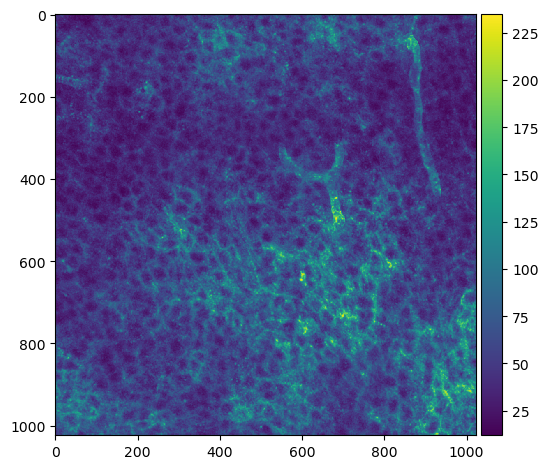

In [174]:
mask = io.imread(path.join(manifest.loc[idx]['Dirname'],
                           str(manifest.loc[idx]['FOV']) +'_mask.tif')).astype(bool)
bm_MIP = bm_a6_intensity[13:22,...].max(axis=0).T
mean_curvature_masked = mean_curvature.copy()
mean_curvature_masked[~mask] = np.nan
bm_MIP_smooth_masked = bm_MIP.copy().astype(float)
bm_MIP_smooth_masked[~mask] = np.nan

io.imshow(bm_MIP)
io.imsave( path.join(manifest.loc[idx]['Dirname'],'bm_a6_intensity.tif'), bm_a6_intensity)


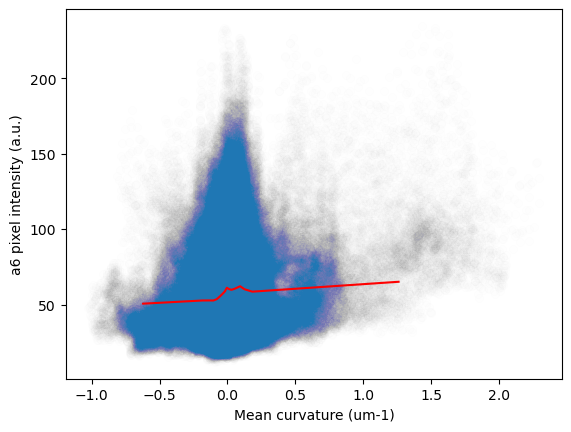

<Figure size 640x480 with 0 Axes>

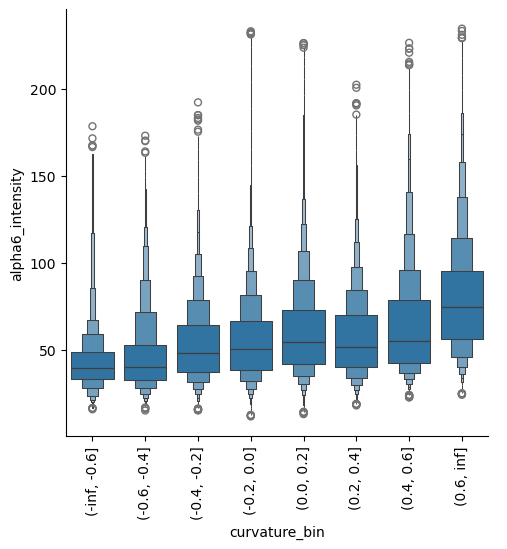

In [175]:
from basicUtils import plot_bin_means

plt.scatter(mean_curvature_masked.flatten(),bm_MIP_smooth_masked.flatten(), alpha=0.005)
plot_bin_means(mean_curvature_masked.flatten(),bm_MIP_smooth_masked.flatten(),bin_edges=18,color='r',
               bin_style='percentile',mean='mean')
plt.xlabel('Mean curvature (um-1)'),
plt.ylabel('a6 pixel intensity (a.u.)')
# plt.hlines(np.nanmean(bm_MIP_smooth.flatten()),xmin= -0.4,xmax=0.5)

plt.figure()
df = pd.DataFrame.from_dict({'curvature':mean_curvature_masked.flatten(),
                             'alpha6_intensity':bm_MIP_smooth_masked.flatten()}).dropna()
df['curvature_bin'],bins = pd.cut(df['curvature'],bins=[-np.inf,-.6,-.4,-.2,0,.2,.4,.6,np.inf],retbins=True)
sb.catplot(df,x='curvature_bin',y='alpha6_intensity',kind='boxen')

plt.xticks(rotation=90)

df.to_csv(path.join(manifest.loc[idx]['Dirname'],'a6_intensity.csv'))

In [45]:
# Summarize

In [171]:

dirname = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/05-24-2026 ASAP uninduced antibody tests/DAPI alpha6488/'

df = []
for i,f in enumerate(glob(path.join(dirname,'[58]/a6_intensity.csv'))):
    _df = pd.read_csv(f,index_col=0)
    _df['Region'] = i
    _df['Mean a6'] = _df['alpha6_intensity'].mean()
    df.append(_df)
df = pd.concat(df,ignore_index=True)
df['curvature_bin'],bins = pd.cut(df['curvature'],bins=[-np.inf,-.6,-.4,-.2,0,.2,.4,.6,np.inf],retbins=True)
df['Concavity'] = df['curvature'] > 0

df['a6_norm'] = df['alpha6_intensity'] / df['Mean a6']

In [165]:
glob(path.join(dirname,'[58]/a6_intensity.csv'))

['/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/05-24-2026 ASAP uninduced antibody tests/DAPI alpha6488/8/a6_intensity.csv',
 '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Fixed/05-24-2026 ASAP uninduced antibody tests/DAPI alpha6488/5/a6_intensity.csv']

(np.float64(-64.54966307495228), np.float64(0.0))
(np.float64(-61.86579034826226), np.float64(0.0))


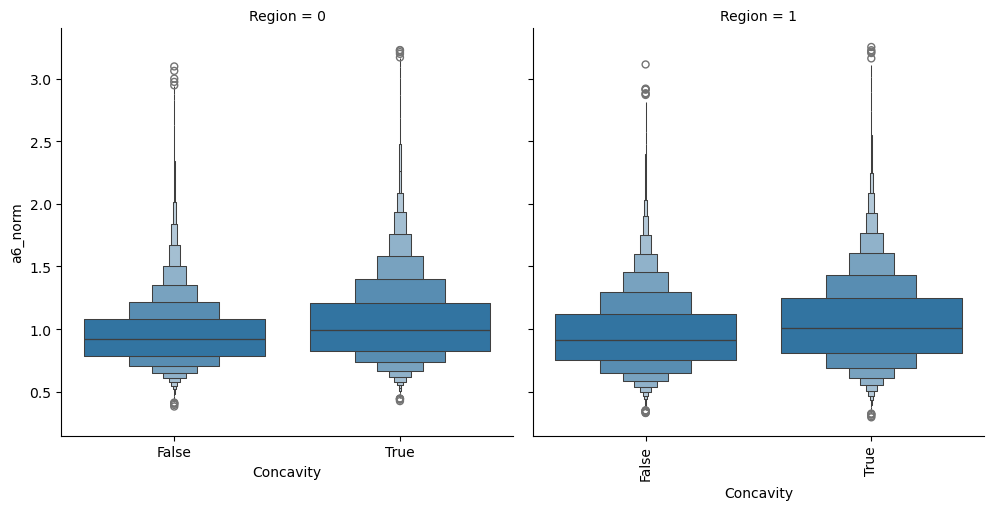

In [178]:
from basicUtils import ttest_from_groupby

sb.catplot(df,x='Concavity',y='a6_norm',col='Region',kind='boxen')
plt.xticks(rotation=90)

for region,_df in df.groupby('Region'):
    print(ttest_from_groupby(_df,field2group='Concavity',field2test='a6_norm'))

In [156]:

df.curvature_bin

15388     (-0.2, 0.0]
15389     (-0.2, 0.0]
15390     (-0.2, 0.0]
15391     (-0.2, 0.0]
15392     (-0.2, 0.0]
             ...     
243149     (0.0, 0.2]
243150     (0.0, 0.2]
243151     (0.0, 0.2]
243152     (0.0, 0.2]
243153     (0.0, 0.2]
Name: curvature_bin, Length: 185400, dtype: category
Categories (8, interval[float64, right]): [(-inf, -0.6] < (-0.6, -0.4] < (-0.4, -0.2] < (-0.2, 0.0] < (0.0, 0.2] < (0.2, 0.4] < (0.4, 0.6] < (0.6, inf]]